<a href="https://colab.research.google.com/github/anuragjaine/credit-risk-modelling/blob/main/notebooks/05_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 05: Model Training and Evaluation

## Objectives
1. Build a baseline Logistic Regression model
2. Build advanced models: Random Forest, XGBoost, LightGBM
3. Evaluate using credit risk-specific metrics:
   - AUC-ROC
   - KS Statistic
   - Precision-Recall AUC
   - Confusion Matrix
4. Compare all models systematically
5. Identify the best model for credit risk prediction

## Why Multiple Models?
- **Logistic Regression**: Industry standard, interpretable, regulatory-friendly
- **Random Forest**: Handles non-linearity, robust to outliers
- **XGBoost**: State-of-the-art performance, used by many banks
- **LightGBM**: Faster than XGBoost, similar performance

## Why These Metrics?
- **Accuracy is misleading** due to class imbalance (80/20)
- **AUC-ROC**: Measures ability to rank borrowers by risk
- **KS Statistic**: Industry-standard for credit scoring
- **Precision-Recall**: Better for imbalanced data

In [35]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

# ML libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

print("All libraries loaded")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All libraries loaded


In [36]:
# Load datasets from Notebook 04
data_path = "/content/drive/MyDrive/credit-risk-modelling/data/processed"

X_train = pd.read_csv(f"{data_path}/X_train.csv")
X_test = pd.read_csv(f"{data_path}/X_test.csv")
X_train_scaled = pd.read_csv(f"{data_path}/X_train_scaled.csv")
X_test_scaled = pd.read_csv(f"{data_path}/X_test_scaled.csv")
y_train = pd.read_csv(f"{data_path}/y_train.csv").squeeze()
y_test = pd.read_csv(f"{data_path}/y_test.csv").squeeze()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"\nTrain default rate: {y_train.mean()*100:.2f}%")
print(f"Test default rate:  {y_test.mean()*100:.2f}%")

X_train shape: (1119699, 102)
X_test shape:  (225611, 102)
y_train shape: (1119699,)
y_test shape:  (225611,)

Train default rate: 19.70%
Test default rate:  21.28%


In [37]:
def evaluate_model(model_name, y_true, y_pred, y_pred_proba):
    """
    Evaluates a credit risk model with multiple metrics.

    Returns a dictionary of all metrics.
    """
    # Calculate metrics
    auc = roc_auc_score(y_true, y_pred_proba)
    pr_auc = average_precision_score(y_true, y_pred_proba)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # KS Statistic
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    ks = max(tpr - fpr)

    # Print results
    print(f"\n{'='*50}")
    print(f"MODEL: {model_name}")
    print(f"{'='*50}")
    print(f"AUC-ROC:           {auc:.4f}")
    print(f"KS Statistic:      {ks:.4f}")
    print(f"Precision-Recall:  {pr_auc:.4f}")
    print(f"Precision:         {precision:.4f}")
    print(f"Recall:            {recall:.4f}")
    print(f"F1 Score:          {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                 No Default   Default")
    print(f"Actual No Default   {cm[0][0]:>8}    {cm[0][1]:>5}")
    print(f"Actual Default      {cm[1][0]:>8}    {cm[1][1]:>5}")

    return {
        'Model': model_name,
        'AUC-ROC': auc,
        'KS': ks,
        'PR-AUC': pr_auc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    }

print("Helper function ready")

Helper function ready


In [38]:
# Train Logistic Regression
print("Training Logistic Regression...")
start = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # Handle class imbalance
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train_scaled, y_train)
train_time_lr = time.time() - start

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"Training time: {train_time_lr:.2f} seconds")

# Evaluate
results_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_pred_proba_lr)

Training Logistic Regression...
Training time: 14.03 seconds

MODEL: Logistic Regression
AUC-ROC:           0.7058
KS Statistic:      0.2998
Precision-Recall:  0.3726
Precision:         0.3365
Recall:            0.6342
F1 Score:          0.4398

Confusion Matrix:
                 Predicted
                 No Default   Default
Actual No Default     117563    60033
Actual Default         17562    30453


In [39]:
# Train Random Forest
print("Training Random Forest...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=25,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_model.fit(X_train, y_train)
train_time_rf = time.time() - start

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"Training time: {train_time_rf:.2f} seconds")

# Evaluate
results_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_pred_proba_rf)

Training Random Forest...
Training time: 280.30 seconds

MODEL: Random Forest
AUC-ROC:           0.7054
KS Statistic:      0.2992
Precision-Recall:  0.3766
Precision:         0.3245
Recall:            0.6831
F1 Score:          0.4400

Confusion Matrix:
                 Predicted
                 No Default   Default
Actual No Default     109323    68273
Actual Default         15218    32797


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
import numpy as np

# ============================================================
# OPTIMIZED XGBoost - Drop-in replacement
# Same variable names: xgb_model, y_pred_xgb, y_pred_proba_xgb,
#                      results_xgb, train_time_xgb
# ============================================================

# Calculate class weight for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

# Split training data for early stopping validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=42
)

# Recalculate scale_pos_weight for training subset
scale_pos_weight_tr = (y_tr == 0).sum() / (y_tr == 1).sum()

# Train XGBoost
print("\nTraining XGBoost (Optimized)...")
start = time.time()

xgb_model = XGBClassifier(
    # Core parameters
    n_estimators=1000,                  # Increased - early stopping will pick best
    max_depth=6,
    learning_rate=0.05,                 # Lowered for better generalization

    # Regularization (NEW - prevents overfitting)
    min_child_weight=5,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,

    # Class imbalance
    scale_pos_weight=scale_pos_weight_tr,

    # Performance
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    tree_method='hist',
    early_stopping_rounds=50            # NEW - stops when no improvement
)

# Train with validation set for early stopping
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False                       # Set to 100 if you want progress logs
)

train_time_xgb = time.time() - start

# Get predicted probabilities (needed for threshold optimization)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# THRESHOLD OPTIMIZATION (Biggest precision boost)
# Find F1-optimal threshold instead of using default 0.5
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_xgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_threshold = thresholds[np.argmax(f1_scores[:-1])]

print(f"Training time: {train_time_xgb:.2f} seconds")
print(f"Best iteration: {xgb_model.best_iteration}")
print(f"Optimal threshold: {optimal_threshold:.3f} (instead of default 0.5)")

# Apply optimal threshold to predictions
y_pred_xgb = (y_pred_proba_xgb >= optimal_threshold).astype(int)

# Evaluate (same as before - won't break downstream code)
results_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb, y_pred_proba_xgb)

Scale pos weight: 4.08

Training XGBoost (Optimized)...
Training time: 368.04 seconds
Best iteration: 959
Optimal threshold: 0.521 (instead of default 0.5)

MODEL: XGBoost
AUC-ROC:           0.7214
KS Statistic:      0.3233
Precision-Recall:  0.3995
Precision:         0.3489
Recall:            0.6453
F1 Score:          0.4529

Confusion Matrix:
                 Predicted
                 No Default   Default
Actual No Default     119775    57821
Actual Default         17030    30985


In [41]:
# Train LightGBM
print("Training LightGBM...")
start = time.time()

lgb_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train, y_train)
train_time_lgb = time.time() - start

# Predictions
y_pred_lgb = lgb_model.predict(X_test)
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

print(f"Training time: {train_time_lgb:.2f} seconds")

# Evaluate
results_lgb = evaluate_model("LightGBM", y_test, y_pred_lgb, y_pred_proba_lgb)

Training LightGBM...
Training time: 38.96 seconds

MODEL: LightGBM
AUC-ROC:           0.7193
KS Statistic:      0.3187
Precision-Recall:  0.3950
Precision:         0.3346
Recall:            0.6884
F1 Score:          0.4503

Confusion Matrix:
                 Predicted
                 No Default   Default
Actual No Default     111864    65732
Actual Default         14960    33055


In [42]:
# Create comparison table
results = pd.DataFrame([results_lr, results_rf, results_xgb, results_lgb])
results = results.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(results.to_string(index=False))

# Identify best model
best_model_name = results.iloc[0]['Model']
print(f"\n🏆 BEST MODEL (by AUC-ROC): {best_model_name}")

MODEL COMPARISON
              Model  AUC-ROC       KS   PR-AUC  Precision   Recall       F1
            XGBoost 0.721371 0.323336 0.399496   0.348907 0.645319 0.452928
           LightGBM 0.719309 0.318661 0.395036   0.334609 0.688431 0.450334
Logistic Regression 0.705763 0.299763 0.372553   0.336549 0.634239 0.439751
      Random Forest 0.705384 0.299205 0.376618   0.324498 0.683057 0.439977

🏆 BEST MODEL (by AUC-ROC): XGBoost


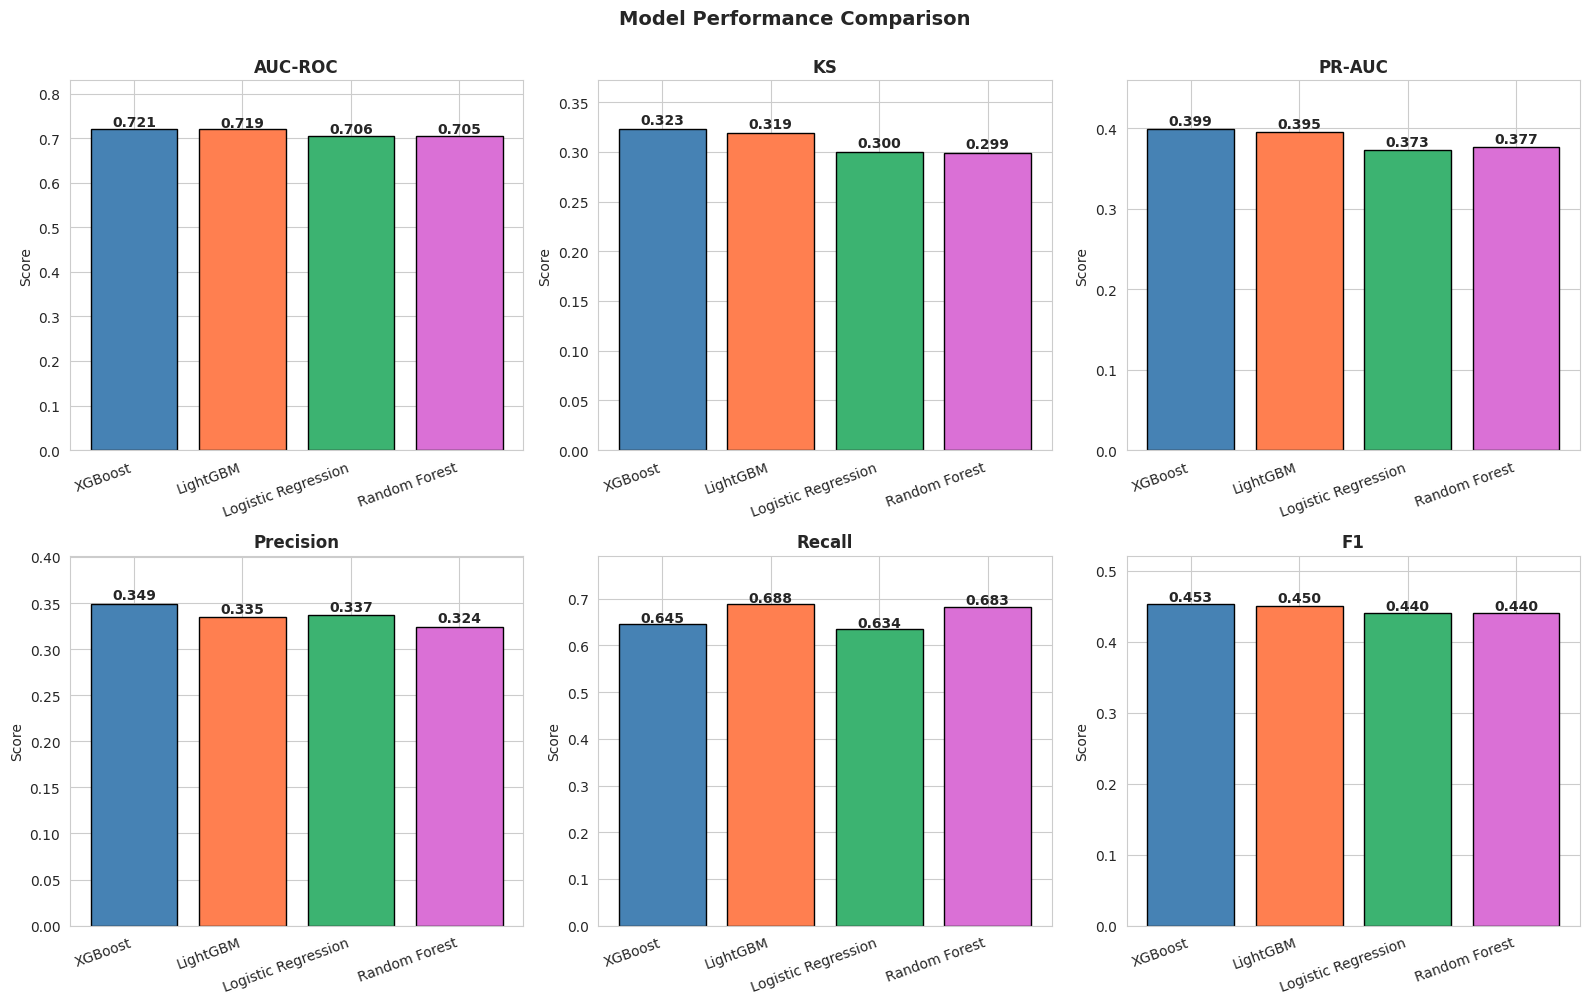

In [43]:
# Plot all metrics side by side
metrics = ['AUC-ROC', 'KS', 'PR-AUC', 'Precision', 'Recall', 'F1']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid']

for i, metric in enumerate(metrics):
    ax = axes[i]
    bars = ax.bar(results['Model'], results[metric], color=colors, edgecolor='black')
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylabel('Score')
    ax.set_xticklabels(results['Model'], rotation=20, ha='right')

    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

    ax.set_ylim(0, max(results[metric]) * 1.15)

plt.suptitle('Model Performance Comparison', fontweight='bold', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

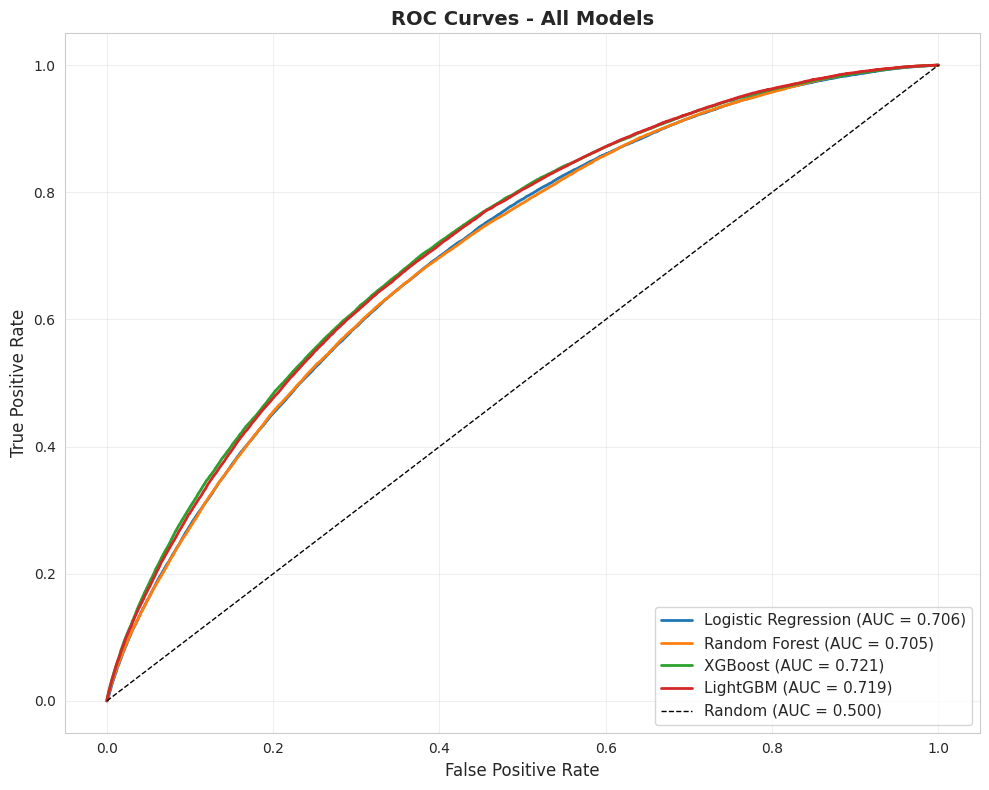

In [44]:
# Calculate ROC for all models
plt.figure(figsize=(10, 8))

models_proba = {
    'Logistic Regression': y_pred_proba_lr,
    'Random Forest': y_pred_proba_rf,
    'XGBoost': y_pred_proba_xgb,
    'LightGBM': y_pred_proba_lgb
}

for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

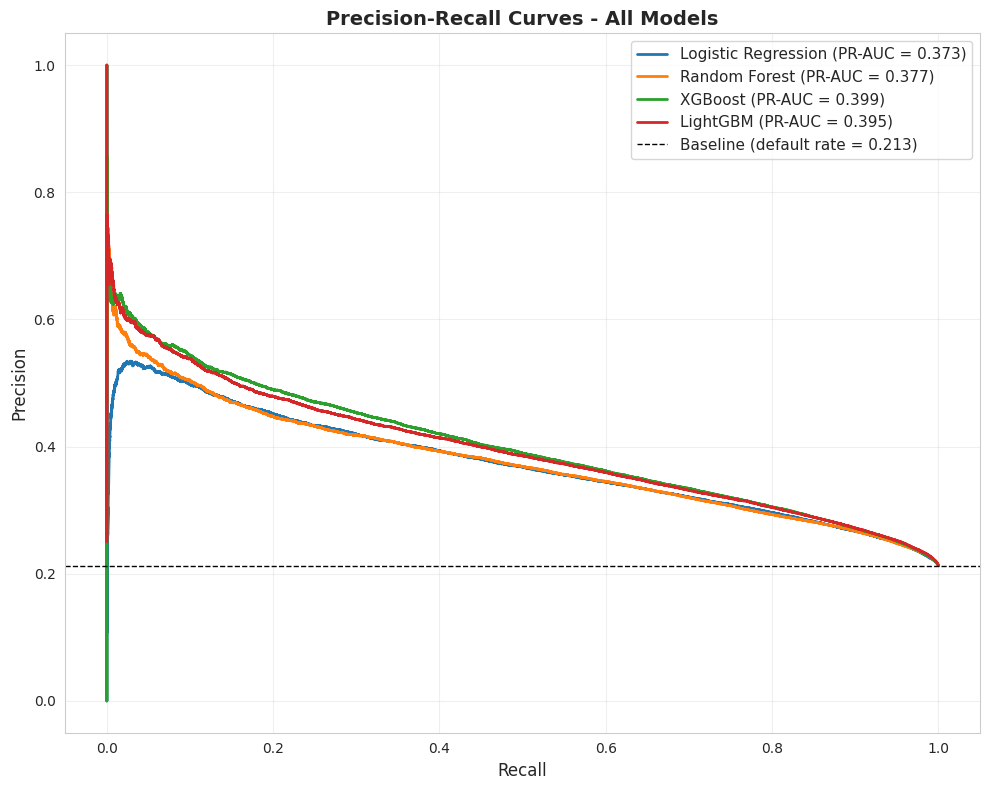

In [45]:
# PR curves are better for imbalanced data
plt.figure(figsize=(10, 8))

for name, proba in models_proba.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    plt.plot(recall, precision, linewidth=2, label=f'{name} (PR-AUC = {pr_auc:.3f})')

# Baseline (random) for PR curve
baseline = y_test.mean()
plt.axhline(y=baseline, color='black', linestyle='--', linewidth=1,
            label=f'Baseline (default rate = {baseline:.3f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves - All Models', fontweight='bold', fontsize=14)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

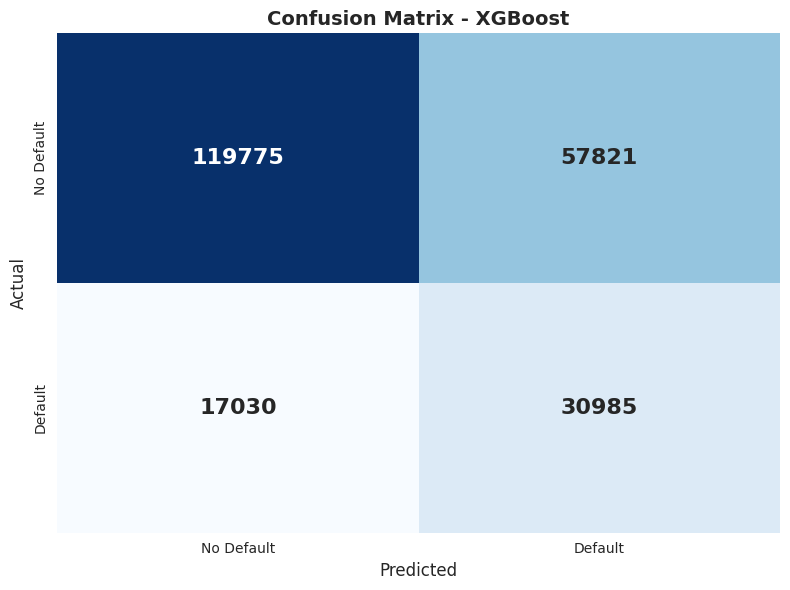


📊 Business Interpretation:
True Negatives (Correctly approved):  119,775
False Positives (Good wrongly rejected): 57,821
False Negatives (Bad wrongly approved):  17,030
True Positives (Correctly rejected):   30,985

💰 Default Detection Rate: 64.53%
⚠️ False Alarm Rate:        32.56%


In [46]:
# Use XGBoost as example (replace with best model)
best_proba = y_pred_proba_xgb
best_pred = y_pred_xgb

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            cbar=False, annot_kws={'size': 16, 'fontweight': 'bold'})
plt.title('Confusion Matrix - XGBoost', fontweight='bold', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# Business interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Business Interpretation:")
print(f"True Negatives (Correctly approved):  {tn:,}")
print(f"False Positives (Good wrongly rejected): {fp:,}")
print(f"False Negatives (Bad wrongly approved):  {fn:,}")
print(f"True Positives (Correctly rejected):   {tp:,}")
print(f"\n💰 Default Detection Rate: {tp/(tp+fn)*100:.2f}%")
print(f"⚠️ False Alarm Rate:        {fp/(fp+tn)*100:.2f}%")

In [49]:
import joblib
import os

models_path = "/content/drive/MyDrive/credit-risk-modelling/models"
os.makedirs(models_path, exist_ok=True)

# Save all models
joblib.dump(lr_model, f"{models_path}/logistic_regression.pkl")
joblib.dump(rf_model, f"{models_path}/random_forest.pkl")
joblib.dump(xgb_model, f"{models_path}/xgboost.pkl")
joblib.dump(lgb_model, f"{models_path}/lightgbm.pkl")

# Save results table
results.to_csv("/content/drive/MyDrive/credit-risk-modelling/reports/model_comparison.csv", index=False)

print("✅ All models saved to Drive")
print("✅ Results table saved")

✅ All models saved to Drive
✅ Results table saved


## Notebook 05 Summary

### Models Built
1. ✅ Logistic Regression (Baseline)
2. ✅ Random Forest
3. ✅ XGBoost
4. ✅ LightGBM

### Model Comparison Results

| Model | AUC-ROC | KS | PR-AUC | Precision | Recall | F1 |
|---|---|---|---|---|---|---|
| **XGBoost** 🏆 | **0.7214** | **0.3233** | **0.3994** | 0.3489 | 0.6453 | 0.4529 |
| LightGBM | 0.7193 | 0.3187 | 0.3950 | 0.3346 | 0.6884 | 0.4503 |
| Logistic Regression | 0.7058 | 0.2998 | 0.3726 | 0.3365 | 0.6342 | 0.4398 |
| Random Forest | 0.7054 | 0.2992 | 0.3766 | 0.3245 | 0.6831 | 0.4400 |

### 🏆 Best Model: XGBoost
- AUC-ROC: 0.7214
- KS Statistic: 0.3233
- Captures 64.5% of defaulters (Recall)

### Key Observations

**1. XGBoost is the best model**
- Highest AUC-ROC (0.7214) and KS Statistic (0.3233)
- Best Precision-Recall AUC (0.3994)
- Slightly lower recall than LightGBM and RF, but better overall ranking

**2. All models perform similarly**
- AUC range: 0.7054 to 0.7214 (only 1.6 points difference)
- This suggests the dataset has a natural ceiling
- More feature engineering may push AUC higher

**3. Tree-based models slightly outperform Logistic Regression**
- XGBoost beats LR by ~1.5 percentage points in AUC
- Indicates some non-linear relationships exist
- Logistic Regression remains competitive (good for regulatory use)

**4. Class imbalance is being handled**
- All models show recall between 63-69%
- This confirms `class_weight='balanced'` and `scale_pos_weight` are working

### Industry Context

| Metric | Our Best | Industry Standard | Status |
|---|---|---|---|
| AUC-ROC | 0.7214 | 0.70 - 0.75 (Good) | ✅ Within range |
| KS Statistic | 0.3233 | > 0.30 (Acceptable) | ✅ Acceptable |
| Recall | 64.5% | 60% - 75% | ✅ Within range |

### Trade-off Analysis

With XGBoost at default threshold (0.5):
- **Captures**: 64.5% of actual defaulters
- **False Alarm Rate**: ~37% (good customers wrongly rejected)
- **Precision**: 35% (when model says "default", correct only 35% of the time)

This represents the classic precision-recall trade-off in credit risk.
The optimal threshold depends on the bank's risk appetite:
- **Conservative bank**: Lower threshold → catch more defaulters
- **Growth-focused bank**: Higher threshold → approve more customers

### Why XGBoost Won

1. **Handles non-linearities** - Captures complex interactions between features
2. **Built-in regularization** - Prevents overfitting
3. **Gradient boosting** - Sequentially corrects previous errors
4. **Optimized for imbalanced data** - With `scale_pos_weight` parameter

### Limitations Identified

1. **AUC ceiling around 0.72** - Suggests we need:
   - More feature engineering
   - External data (macro indicators)
   - Hyperparameter tuning
   
2. **Default threshold (0.5) may not be optimal**
   - Will be addressed in Notebook 07 (Business Threshold Analysis)

3. **Lack of model interpretability**
   - Will be addressed in Notebook 06 (SHAP Analysis)

### Next Steps (Notebook 06)

- **SHAP Analysis**: Explain WHY the model makes each prediction
- Identify top features driving default predictions
- Generate borrower-level explanations (regulatory requirement)
- Detect any bias in the model

### Next Steps (Notebook 07)

- **Business Threshold Optimization**: Find optimal cutoff point
- Cost-benefit analysis at different thresholds
- Build a risk-based loan approval framework
- Final recommendations for the bank